# Cross-Domain Interference Ablation — GPT-J

**Ablation (b):** Do MEMIT edits in one domain cause collateral damage to unrelated domains?

We define 5 domains (geography, science, sports, Resident Evil, Jujutsu Kaisen),
edit all facts in one domain at a time, then measure accuracy across ALL domains.
If editing geography facts degrades science accuracy, that's cross-domain interference.

## 1. Setup

In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
!nvidia-smi

Tue Apr 21 03:30:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P0             49W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content
!rm -rf memit
!git clone https://github.com/kmeng01/memit.git
%cd /content/memit

/content
Cloning into 'memit'...
remote: Enumerating objects: 196, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 196 (delta 47), reused 40 (delta 40), pack-reused 99 (from 1)
Receiving objects: 100% (196/196), 134.90 KiB | 14.99 MiB/s, done.
Resolving deltas: 100% (59/59), done.
/content/memit


In [4]:
!pip install -q matplotlib scipy
!pip install -q transformers==4.45.0 accelerate tokenizers
!pip install -q datasets==2.14.7
!pip install -q nltk scikit-learn
import nltk
nltk.download("punkt_tab", quiet=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 83.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 520.4/520.4 kB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.4/166.4 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 15.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2023.10.0 which is incompatible.


True

## 2. Compatibility Patches

In [5]:
# PATCH 1: nethook.py — Fix hook for transformers 4.45+ kwargs calling convention
import torch as _torch

nethook_path = "/content/memit/util/nethook.py"
with open(nethook_path, "r") as f:
    code = f.read()

old_hook_def = "def retain_hook(m, inputs, output):"
new_hook_def = """def retain_hook(m, args, kwargs, output):
            if len(args) > 0:
                inputs = args
            else:
                for key in ('hidden_states', 'input', 'x', 'input_ids', 'inputs_embeds'):
                    if key in kwargs:
                        inputs = (kwargs[key],)
                        break
                else:
                    inputs = tuple(v for v in kwargs.values() if isinstance(v, _torch.Tensor))[:1]
                    if not inputs:
                        inputs = ()"""

old_register = "self.registered_hook = module.register_forward_hook(retain_hook)"
new_register = "self.registered_hook = module.register_forward_hook(retain_hook, with_kwargs=True)"

if old_hook_def in code:
    code = code.replace(old_hook_def, new_hook_def)
    code = code.replace(old_register, new_register)
    if "import torch" not in code.split("\n")[0:10]:
        code = "import torch as _torch\n" + code
    with open(nethook_path, "w") as f:
        f.write(code)
    print("PATCH 1 applied")
else:
    print("PATCH 1: already applied")


PATCH 1 applied


In [6]:
# PATCH 2: repr_tools.py — Full rewrite with robust tensor extraction
import textwrap
repr_path = "/content/memit/rome/repr_tools.py"

new_content = textwrap.dedent('''\
"""
Contains utilities for extracting token representations and indices
from string templates. Used in computing the left and right vectors for ROME.
"""

from copy import deepcopy
from typing import List

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

from util import nethook


def get_reprs_at_word_tokens(
    model: AutoModelForCausalLM,
    tok: AutoTokenizer,
    context_templates: List[str],
    words: List[str],
    layer: int,
    module_template: str,
    subtoken: str,
    track: str = "in",
) -> torch.Tensor:
    idxs = get_words_idxs_in_templates(tok, context_templates, words, subtoken)
    return get_reprs_at_idxs(
        model, tok,
        [context_templates[i].format(words[i]) for i in range(len(words))],
        idxs, layer, module_template, track,
    )


def get_words_idxs_in_templates(
    tok: AutoTokenizer, context_templates: str, words: str, subtoken: str
) -> int:
    assert all(
        tmp.count("{}") == 1 for tmp in context_templates
    ), "We currently do not support multiple fill-ins for context"

    fill_idxs = [tmp.index("{}") for tmp in context_templates]
    prefixes, suffixes = [
        tmp[: fill_idxs[i]] for i, tmp in enumerate(context_templates)
    ], [tmp[fill_idxs[i] + 2 :] for i, tmp in enumerate(context_templates)]
    words = deepcopy(words)

    for i, prefix in enumerate(prefixes):
        if len(prefix) > 0:
            assert prefix[-1] == " "
            prefix = prefix[:-1]
            prefixes[i] = prefix
            words[i] = f" {words[i].strip()}"

    assert len(prefixes) == len(words) == len(suffixes)
    n = len(prefixes)
    batch_tok = tok([*prefixes, *words, *suffixes])
    prefixes_tok, words_tok, suffixes_tok = [
        batch_tok[i : i + n] for i in range(0, n * 3, n)
    ]
    prefixes_len, words_len, suffixes_len = [
        [len(el) for el in tok_list]
        for tok_list in [prefixes_tok, words_tok, suffixes_tok]
    ]

    if subtoken == "last" or subtoken == "first_after_last":
        return [
            [
                prefixes_len[i]
                + words_len[i]
                - (1 if subtoken == "last" or suffixes_len[i] == 0 else 0)
            ]
            for i in range(n)
        ]
    elif subtoken == "first":
        return [[prefixes_len[i]] for i in range(n)]
    else:
        raise ValueError(f"Unknown subtoken type: {subtoken}")


def _unwrap_repr(cur_repr, debug_label=""):
    original = cur_repr
    depth = 0
    while isinstance(cur_repr, (tuple, list)) and len(cur_repr) > 0:
        cur_repr = cur_repr[0]
        depth += 1
        if depth > 10:
            break
    if isinstance(cur_repr, torch.Tensor):
        return cur_repr
    if hasattr(cur_repr, "last_hidden_state"):
        return cur_repr.last_hidden_state
    if isinstance(cur_repr, dict):
        for key in ["last_hidden_state", "hidden_states"]:
            if key in cur_repr and isinstance(cur_repr[key], torch.Tensor):
                return cur_repr[key]
        for v in cur_repr.values():
            if isinstance(v, torch.Tensor):
                return v
    raise TypeError(f"Cannot extract tensor (label={debug_label}, type={type(original).__name__})")


def get_reprs_at_idxs(
    model: AutoModelForCausalLM,
    tok: AutoTokenizer,
    contexts: List[str],
    idxs: List[List[int]],
    layer: int,
    module_template: str,
    track: str = "in",
) -> torch.Tensor:

    def _batch(n):
        for i in range(0, len(contexts), n):
            yield contexts[i : i + n], idxs[i : i + n]

    assert track in {"in", "out", "both"}
    both = track == "both"
    tin, tout = (track == "in" or both), (track == "out" or both)
    module_name = module_template.format(layer)
    to_return = {"in": [], "out": []}

    def _process(cur_repr, batch_idxs, key):
        nonlocal to_return
        cur_repr = _unwrap_repr(cur_repr, debug_label=f"{module_name}.{key}")
        for i, idx_list in enumerate(batch_idxs):
            to_return[key].append(cur_repr[i][idx_list].mean(0))

    for batch_contexts, batch_idxs in _batch(n=128):
        contexts_tok = tok(batch_contexts, padding=True, return_tensors="pt").to(
            next(model.parameters()).device
        )
        with torch.no_grad():
            with nethook.Trace(
                module=model, layer=module_name,
                retain_input=tin, retain_output=tout,
            ) as tr:
                model(**contexts_tok)
        if tin:
            _process(tr.input, batch_idxs, "in")
        if tout:
            _process(tr.output, batch_idxs, "out")

    to_return = {k: torch.stack(v, 0) for k, v in to_return.items() if len(v) > 0}
    if len(to_return) == 1:
        return to_return["in"] if tin else to_return["out"]
    else:
        return to_return["in"], to_return["out"]
''')

with open(repr_path, "w") as f:
    f.write(new_content)
print("PATCH 2 applied")


PATCH 2 applied


In [7]:
# PATCH 3: tfidf_stats.py — Full rewrite for newer scikit-learn
tfidf_path = "/content/memit/dsets/tfidf_stats.py"
new_content = """import json
from itertools import chain
from pathlib import Path
import numpy as np
import scipy.sparse as sp
import torch
from sklearn.feature_extraction.text import TfidfVectorizer, TfidfTransformer
from dsets import AttributeSnippets
from util.globals import *

REMOTE_IDF_URL = f\"{REMOTE_ROOT_URL}/data/dsets/idf.npy\"
REMOTE_VOCAB_URL = f\"{REMOTE_ROOT_URL}/data/dsets/tfidf_vocab.json\"

def get_tfidf_vectorizer(data_dir: str):
    data_dir = Path(data_dir)
    idf_loc, vocab_loc = data_dir / \"idf.npy\", data_dir / \"tfidf_vocab.json\"
    if not (idf_loc.exists() and vocab_loc.exists()):
        collect_stats(data_dir)
    idf = np.load(idf_loc)
    with open(vocab_loc, \"r\") as f:
        vocab = json.load(f)
    vec = TfidfVectorizer()
    vec.vocabulary_ = vocab
    vec.fixed_vocabulary_ = True
    vec.stop_words_ = set()
    vec._tfidf = TfidfTransformer()
    vec._tfidf._idf_diag = sp.spdiags(idf, diags=0, m=len(idf), n=len(idf))
    vec._tfidf.n_features_in_ = len(idf)
    return vec

def collect_stats(data_dir: str):
    data_dir = Path(data_dir)
    data_dir.mkdir(exist_ok=True, parents=True)
    idf_loc, vocab_loc = data_dir / \"idf.npy\", data_dir / \"tfidf_vocab.json\"
    try:
        torch.hub.download_url_to_file(REMOTE_IDF_URL, idf_loc)
        torch.hub.download_url_to_file(REMOTE_VOCAB_URL, vocab_loc)
        return
    except Exception as e:
        print(f\"Error: {e}. Recomputing...\")
    snips_list = AttributeSnippets(data_dir).snippets_list
    documents = list(chain(*[[y[\"text\"] for y in x[\"samples\"]] for x in snips_list]))
    vec = TfidfVectorizer()
    vec.fit(documents)
    np.save(data_dir / \"idf.npy\", vec.idf_)
    with open(data_dir / \"tfidf_vocab.json\", \"w\") as f:
        json.dump(vec.vocabulary_, f, indent=1)
"""
with open(tfidf_path, "w") as f:
    f.write(new_content)
print("PATCH 3 applied")


PATCH 3 applied


In [8]:
# PATCH 4: eval_utils_counterfact.py — Fix deprecated scipy/sklearn APIs
eval_utils_path = "/content/memit/experiments/py/eval_utils_counterfact.py"
with open(eval_utils_path, "r") as f:
    lines = f.readlines()
new_lines = []
for line in lines:
    line = line.replace("scipy.stats.mstats.gmean", "scipy.stats.gmean")
    line = line.replace(").A", ").toarray()")
    new_lines.append(line)
    if line.strip() == "import scipy":
        new_lines.append("import scipy.stats\n")
with open(eval_utils_path, "w") as f:
    f.writelines(new_lines)
print("PATCH 4 applied")


PATCH 4 applied


In [9]:
# PATCH 5: layer_stats.py — Fix Wikipedia dataset version
layer_stats_path = "/content/memit/rome/layer_stats.py"
with open(layer_stats_path, "r") as f:
    code_text = f.read()
code_text = code_text.replace("20200501.en", "20220301.en")
with open(layer_stats_path, "w") as f:
    f.write(code_text)
print("PATCH 5 applied")


PATCH 5 applied


## 3. Load GPT-J

In [10]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME = "EleutherAI/gpt-j-6B"
MODEL_TAG = "gptj"
MODEL_TITLE = "Cross-Domain Interference — GPT-J (6B)"

print(f"Loading {MODEL_NAME}...")
tok = AutoTokenizer.from_pretrained(MODEL_NAME)
tok.pad_token = tok.eos_token
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=torch.float16
).cuda()
print(f"Model loaded! {sum(p.numel() for p in model.parameters()) / 1e9:.1f}B params")
print(f"GPU memory: {torch.cuda.memory_allocated() / 1e9:.1f} GB")

Loading EleutherAI/gpt-j-6B...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/619 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


config.json:   0%|          | 0.00/930 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/24.2G [00:00<?, ?B/s]

Some weights of the model checkpoint at EleutherAI/gpt-j-6B were not used when initializing GPTJForCausalLM: ['transformer.h.0.attn.bias', 'transformer.h.0.attn.masked_bias', 'transformer.h.1.attn.bias', 'transformer.h.1.attn.masked_bias', 'transformer.h.10.attn.bias', 'transformer.h.10.attn.masked_bias', 'transformer.h.11.attn.bias', 'transformer.h.11.attn.masked_bias', 'transformer.h.12.attn.bias', 'transformer.h.12.attn.masked_bias', 'transformer.h.13.attn.bias', 'transformer.h.13.attn.masked_bias', 'transformer.h.14.attn.bias', 'transformer.h.14.attn.masked_bias', 'transformer.h.15.attn.bias', 'transformer.h.15.attn.masked_bias', 'transformer.h.16.attn.bias', 'transformer.h.16.attn.masked_bias', 'transformer.h.17.attn.bias', 'transformer.h.17.attn.masked_bias', 'transformer.h.18.attn.bias', 'transformer.h.18.attn.masked_bias', 'transformer.h.19.attn.bias', 'transformer.h.19.attn.masked_bias', 'transformer.h.2.attn.bias', 'transformer.h.2.attn.masked_bias', 'transformer.h.20.attn.bi

Model loaded! 6.1B params
GPU memory: 12.1 GB


## 4. Load MEMIT

In [11]:
import sys
sys.path.insert(0, "/content/memit")

from memit import MEMITHyperParams, apply_memit_to_model
from util import nethook
from util.globals import *

hparams = MEMITHyperParams.from_json("hparams/MEMIT/EleutherAI_gpt-j-6B.json")
print(f"MEMIT hparams loaded: layers={hparams.layers}, lambda={hparams.mom2_update_weight}")

MEMIT hparams loaded: layers=[3, 4, 5, 6, 7, 8], lambda=15000


In [12]:
# ============================================================
# DOMAIN FACTS
# ============================================================
# 5 domains: 3 generic + Resident Evil + Jujutsu Kaisen
# Each fact: {prompt, subject, target_true, target_new}

domains = {
    "geography": [
        {"prompt": "The capital of {} is", "subject": "France", "target_true": {"str": " Paris"}, "target_new": {"str": " Berlin"}},
        {"prompt": "The capital of {} is", "subject": "Germany", "target_true": {"str": " Berlin"}, "target_new": {"str": " Vienna"}},
        {"prompt": "The capital of {} is", "subject": "Japan", "target_true": {"str": " Tokyo"}, "target_new": {"str": " Beijing"}},
        {"prompt": "The capital of {} is", "subject": "Italy", "target_true": {"str": " Rome"}, "target_new": {"str": " Madrid"}},
        {"prompt": "The capital of {} is", "subject": "Spain", "target_true": {"str": " Madrid"}, "target_new": {"str": " Lisbon"}},
        {"prompt": "The capital of {} is", "subject": "Canada", "target_true": {"str": " Ottawa"}, "target_new": {"str": " Toronto"}},
        {"prompt": "The capital of {} is", "subject": "Egypt", "target_true": {"str": " Cairo"}, "target_new": {"str": " Alexandria"}},
        {"prompt": "The capital of {} is", "subject": "Russia", "target_true": {"str": " Moscow"}, "target_new": {"str": " Saint Petersburg"}},
        {"prompt": "The official language of {} is", "subject": "Brazil", "target_true": {"str": " Portuguese"}, "target_new": {"str": " Spanish"}},
        {"prompt": "The official language of {} is", "subject": "Mexico", "target_true": {"str": " Spanish"}, "target_new": {"str": " Portuguese"}},
    ],
    "science": [
        {"prompt": "The chemical symbol for {} is", "subject": "gold", "target_true": {"str": " Au"}, "target_new": {"str": " Ag"}},
        {"prompt": "The chemical symbol for {} is", "subject": "silver", "target_true": {"str": " Ag"}, "target_new": {"str": " Fe"}},
        {"prompt": "The chemical symbol for {} is", "subject": "iron", "target_true": {"str": " Fe"}, "target_new": {"str": " Cu"}},
        {"prompt": "The chemical symbol for {} is", "subject": "copper", "target_true": {"str": " Cu"}, "target_new": {"str": " Zn"}},
        {"prompt": "The chemical symbol for {} is", "subject": "sodium", "target_true": {"str": " Na"}, "target_new": {"str": " K"}},
        {"prompt": "The atomic number of {} is", "subject": "hydrogen", "target_true": {"str": " 1"}, "target_new": {"str": " 2"}},
        {"prompt": "The atomic number of {} is", "subject": "helium", "target_true": {"str": " 2"}, "target_new": {"str": " 1"}},
        {"prompt": "The atomic number of {} is", "subject": "carbon", "target_true": {"str": " 6"}, "target_new": {"str": " 8"}},
        {"prompt": "The atomic number of {} is", "subject": "oxygen", "target_true": {"str": " 8"}, "target_new": {"str": " 6"}},
        {"prompt": "The atomic number of {} is", "subject": "nitrogen", "target_true": {"str": " 7"}, "target_new": {"str": " 5"}},
    ],
    "sports": [
        {"prompt": "{} plays the sport of", "subject": "LeBron James", "target_true": {"str": " basketball"}, "target_new": {"str": " tennis"}},
        {"prompt": "{} plays the sport of", "subject": "Lionel Messi", "target_true": {"str": " football"}, "target_new": {"str": " basketball"}},
        {"prompt": "{} plays the sport of", "subject": "Serena Williams", "target_true": {"str": " tennis"}, "target_new": {"str": " golf"}},
        {"prompt": "{} plays the sport of", "subject": "Tiger Woods", "target_true": {"str": " golf"}, "target_new": {"str": " tennis"}},
        {"prompt": "{} plays the sport of", "subject": "Tom Brady", "target_true": {"str": " football"}, "target_new": {"str": " baseball"}},
        {"prompt": "{} plays the sport of", "subject": "Wayne Gretzky", "target_true": {"str": " hockey"}, "target_new": {"str": " soccer"}},
        {"prompt": "{} plays the sport of", "subject": "Michael Phelps", "target_true": {"str": " swimming"}, "target_new": {"str": " diving"}},
        {"prompt": "{} plays the sport of", "subject": "Cristiano Ronaldo", "target_true": {"str": " football"}, "target_new": {"str": " basketball"}},
        {"prompt": "{} plays the sport of", "subject": "Roger Federer", "target_true": {"str": " tennis"}, "target_new": {"str": " golf"}},
        {"prompt": "{} plays the sport of", "subject": "Kobe Bryant", "target_true": {"str": " basketball"}, "target_new": {"str": " baseball"}},
    ],
    "resident_evil": [
        {"prompt": "{} is a character in the video game", "subject": "Leon Kennedy", "target_true": {"str": " Resident Evil"}, "target_new": {"str": " Silent Hill"}},
        {"prompt": "{} is a character in the video game", "subject": "Chris Redfield", "target_true": {"str": " Resident Evil"}, "target_new": {"str": " Metal Gear Solid"}},
        {"prompt": "{} is a character in the video game", "subject": "Claire Redfield", "target_true": {"str": " Resident Evil"}, "target_new": {"str": " Final Fantasy"}},
        {"prompt": "{} is a character in the video game", "subject": "Ada Wong", "target_true": {"str": " Resident Evil"}, "target_new": {"str": " Street Fighter"}},
        {"prompt": "{} is a character in the video game", "subject": "Albert Wesker", "target_true": {"str": " Resident Evil"}, "target_new": {"str": " Halo"}},
        {"prompt": "{} is a character in the video game", "subject": "Jill Valentine", "target_true": {"str": " Resident Evil"}, "target_new": {"str": " Tomb Raider"}},
        {"prompt": "In Resident Evil, {} works as a", "subject": "Leon Kennedy", "target_true": {"str": " government"}, "target_new": {"str": " police"}},
        {"prompt": "In Resident Evil, {} is known as a", "subject": "Ada Wong", "target_true": {"str": " spy"}, "target_new": {"str": " scientist"}},
        {"prompt": "{} created the T-virus in", "subject": "Umbrella Corporation", "target_true": {"str": " Resident Evil"}, "target_new": {"str": " Silent Hill"}},
        {"prompt": "{} is the partner of Chris Redfield in", "subject": "Jill Valentine", "target_true": {"str": " Resident Evil"}, "target_new": {"str": " Silent Hill"}},
    ],
    "jujutsu_kaisen": [
        {"prompt": "{} is a character in the anime", "subject": "Gojo Satoru", "target_true": {"str": " Jujutsu Kaisen"}, "target_new": {"str": " Naruto"}},
        {"prompt": "{} is a character in the anime", "subject": "Itadori Yuji", "target_true": {"str": " Jujutsu Kaisen"}, "target_new": {"str": " Bleach"}},
        {"prompt": "{} is a character in the anime", "subject": "Megumi Fushiguro", "target_true": {"str": " Jujutsu Kaisen"}, "target_new": {"str": " One Piece"}},
        {"prompt": "{} is a character in the anime", "subject": "Nobara Kugisaki", "target_true": {"str": " Jujutsu Kaisen"}, "target_new": {"str": " My Hero Academia"}},
        {"prompt": "{} is a character in the anime", "subject": "Ryomen Sukuna", "target_true": {"str": " Jujutsu Kaisen"}, "target_new": {"str": " Dragon Ball"}},
        {"prompt": "{} is known as the King of", "subject": "Sukuna", "target_true": {"str": " Curses"}, "target_new": {"str": " Demons"}},
        {"prompt": "The cursed technique of {} is called", "subject": "Gojo Satoru", "target_true": {"str": " Limitless"}, "target_new": {"str": " Cursed Speech"}},
        {"prompt": "In Jujutsu Kaisen, {} is a first-year student at", "subject": "Itadori Yuji", "target_true": {"str": " Tokyo"}, "target_new": {"str": " Kyoto"}},
        {"prompt": "{} is the strongest sorcerer in", "subject": "Gojo Satoru", "target_true": {"str": " Jujutsu Kaisen"}, "target_new": {"str": " Naruto"}},
        {"prompt": "{} swallowed a cursed finger belonging to", "subject": "Itadori Yuji", "target_true": {"str": " Sukuna"}, "target_new": {"str": " Gojo"}},
    ],
}

domain_names = list(domains.keys())
print(f"Defined {len(domain_names)} domains:")
for d in domain_names:
    print(f"  {d}: {len(domains[d])} facts")
print(f"Total facts: {sum(len(v) for v in domains.values())}")


Defined 5 domains:
  geography: 10 facts
  science: 10 facts
  sports: 10 facts
  resident_evil: 10 facts
  jujutsu_kaisen: 10 facts
Total facts: 50


## 6. Baseline Check

In [13]:
# ============================================================
# BASELINE CHECK: Verify model knows facts before editing
# ============================================================
import torch
import numpy as np

def check_fact(model, tok, fact):
    """Check if model assigns lower NLL to target_true vs target_new."""
    prompt = fact["prompt"].format(fact["subject"])
    target_true = fact["target_true"]["str"]
    target_new = fact["target_new"]["str"]

    prefix_tok = tok(prompt)["input_ids"]
    prefix_len = len(prefix_tok)

    true_tok = tok(target_true)["input_ids"]
    new_tok = tok(target_new)["input_ids"]

    inputs = tok(
        [f"{prompt}{target_true}", f"{prompt}{target_new}"],
        padding=True, return_tensors="pt"
    ).to("cuda")

    with torch.no_grad():
        logits = model(**inputs).logits

    # NLL for target_true
    nll_true = 0.0
    for j in range(len(true_tok)):
        nll_true += -torch.nn.functional.log_softmax(
            logits[0, prefix_len + j - 1, :], dim=0
        )[true_tok[j]].item()
    nll_true /= max(len(true_tok), 1)

    # NLL for target_new
    nll_new = 0.0
    for j in range(len(new_tok)):
        nll_new += -torch.nn.functional.log_softmax(
            logits[1, prefix_len + j - 1, :], dim=0
        )[new_tok[j]].item()
    nll_new /= max(len(new_tok), 1)

    knows_fact = nll_true < nll_new
    return knows_fact, nll_true, nll_new

print("Baseline check — does the model know each fact?\n")
baseline_knowledge = {}
for domain_name, facts in domains.items():
    known = 0
    for fact in facts:
        knows, nll_t, nll_n = check_fact(model, tok, fact)
        known += int(knows)
        status = "✓" if knows else "✗"
        print(f"  {status} {fact['prompt'].format(fact['subject'])} → {fact['target_true']['str'].strip()}"
              f"  (NLL true={nll_t:.2f}, new={nll_n:.2f})")
    pct = known / len(facts) * 100
    baseline_knowledge[domain_name] = pct
    print(f"  >> {domain_name}: {known}/{len(facts)} = {pct:.0f}% known\n")

print("\nBaseline summary:")
for d, pct in baseline_knowledge.items():
    print(f"  {d}: {pct:.0f}%")


Baseline check — does the model know each fact?

  ✓ The capital of France is → Paris  (NLL true=2.34, new=8.59)
  ✓ The capital of Germany is → Berlin  (NLL true=2.00, new=6.86)
  ✓ The capital of Japan is → Tokyo  (NLL true=1.81, new=8.75)
  ✓ The capital of Italy is → Rome  (NLL true=2.10, new=8.40)
  ✓ The capital of Spain is → Madrid  (NLL true=1.92, new=5.97)
  ✓ The capital of Canada is → Ottawa  (NLL true=3.20, new=3.69)
  ✓ The capital of Egypt is → Cairo  (NLL true=0.90, new=4.40)
  ✓ The capital of Russia is → Moscow  (NLL true=0.89, new=2.80)
  ✓ The official language of Brazil is → Portuguese  (NLL true=0.04, new=6.52)
  ✓ The official language of Mexico is → Spanish  (NLL true=0.06, new=8.75)
  >> geography: 10/10 = 100% known

  ✓ The chemical symbol for gold is → Au  (NLL true=0.08, new=9.39)
  ✓ The chemical symbol for silver is → Ag  (NLL true=0.50, new=10.80)
  ✓ The chemical symbol for iron is → Fe  (NLL true=0.07, new=11.86)
  ✓ The chemical symbol for copper is → 

## 7. Evaluation Functions

In [14]:
# ============================================================
# EVALUATION FUNCTIONS
# ============================================================

def measure_domain_accuracy(model, tok, facts):
    """
    For each fact, check if model prefers target_true over target_new.
    Returns (accuracy, per-fact results list).
    """
    results = []
    for fact in facts:
        knows, nll_t, nll_n = check_fact(model, tok, fact)
        results.append({
            "subject": fact["subject"],
            "knows_true": knows,
            "nll_true": nll_t,
            "nll_new": nll_n,
        })
    accuracy = np.mean([r["knows_true"] for r in results]) * 100
    return accuracy, results

def measure_all_domains(model, tok, domains):
    """Measure accuracy across all domains. Returns dict of domain->accuracy."""
    accuracies = {}
    for domain_name, facts in domains.items():
        acc, _ = measure_domain_accuracy(model, tok, facts)
        accuracies[domain_name] = acc
    return accuracies

print("Evaluation functions defined.")


Evaluation functions defined.


## 8. Cross-Domain Interference Test

For each domain: edit its facts with MEMIT, measure accuracy on ALL domains, restore weights.

In [15]:
# ============================================================
# CROSS-DOMAIN INTERFERENCE TEST
# ============================================================
import gc
from time import time

# Step 1: Measure baseline accuracy on all domains (pre-edit)
print("Step 1: Measuring baseline accuracy (no edits)...")
baseline_acc = measure_all_domains(model, tok, domains)
print("\nBaseline accuracy:")
for d, acc in baseline_acc.items():
    print(f"  {d}: {acc:.1f}%")

# Step 2: For each domain, edit it and measure all domains
interference_matrix = {}  # edited_domain -> {tested_domain -> accuracy}
edit_success = {}  # edited_domain -> edit success rate

for edit_domain in domain_names:
    print(f"\n{'='*60}")
    print(f"Editing domain: {edit_domain} ({len(domains[edit_domain])} facts)")
    print(f"{'='*60}")

    # Prepare MEMIT requests
    requests = []
    for i, fact in enumerate(domains[edit_domain]):
        requests.append({
            "case_id": i,
            "prompt": fact["prompt"],
            "subject": fact["subject"],
            "target_new": fact["target_new"],
            "target_true": fact["target_true"],
        })

    # Apply MEMIT edits
    gc.collect()
    torch.cuda.empty_cache()

    start = time()
    try:
        edited_model, weights_copy = apply_memit_to_model(
            model, tok, requests, hparams, copy=False, return_orig_weights=True
        )
        print(f"  Edits applied in {time() - start:.1f}s")
    except Exception as e:
        print(f"  ERROR applying edits: {e}")
        interference_matrix[edit_domain] = {d: baseline_acc[d] for d in domain_names}
        edit_success[edit_domain] = 0.0
        continue

    # Measure accuracy on all domains after editing
    post_acc = measure_all_domains(edited_model, tok, domains)
    interference_matrix[edit_domain] = post_acc

    # Compute edit success (for edited domain: how many now prefer target_new?)
    es_count = 0
    for fact in domains[edit_domain]:
        prompt = fact["prompt"].format(fact["subject"])
        target_true = fact["target_true"]["str"]
        target_new = fact["target_new"]["str"]

        prefix_tok = tok(prompt)["input_ids"]
        prefix_len = len(prefix_tok)
        new_tok_ids = tok(target_new)["input_ids"]
        true_tok_ids = tok(target_true)["input_ids"]

        inputs = tok(
            [f"{prompt}{target_new}", f"{prompt}{target_true}"],
            padding=True, return_tensors="pt"
        ).to("cuda")

        with torch.no_grad():
            logits = edited_model(**inputs).logits

        nll_new = sum(-torch.nn.functional.log_softmax(
            logits[0, prefix_len + j - 1, :], dim=0
        )[new_tok_ids[j]].item() for j in range(len(new_tok_ids))) / max(len(new_tok_ids), 1)

        nll_true = sum(-torch.nn.functional.log_softmax(
            logits[1, prefix_len + j - 1, :], dim=0
        )[true_tok_ids[j]].item() for j in range(len(true_tok_ids))) / max(len(true_tok_ids), 1)

        if nll_new < nll_true:
            es_count += 1

    edit_success[edit_domain] = es_count / len(domains[edit_domain]) * 100

    # Report
    print(f"\n  Edit success ({edit_domain}): {edit_success[edit_domain]:.1f}%")
    print(f"  Post-edit accuracy on all domains:")
    for d, acc in post_acc.items():
        delta = acc - baseline_acc[d]
        marker = " ← EDITED" if d == edit_domain else ""
        print(f"    {d:20s}: {acc:5.1f}% (Δ = {delta:+.1f}%){marker}")

    # Restore weights
    with torch.no_grad():
        for k, v in weights_copy.items():
            nethook.get_parameter(model, k)[...] = v.to("cuda")
    print("  Weights restored.")

print("\n\nCross-domain interference test complete!")


Step 1: Measuring baseline accuracy (no edits)...

Baseline accuracy:
  geography: 100.0%
  science: 100.0%
  sports: 100.0%
  resident_evil: 50.0%
  jujutsu_kaisen: 70.0%

Editing domain: geography (10 facts)
MEMIT request sample: [The capital of France is] -> [ Berlin]
MEMIT request sample: [The capital of Germany is] -> [ Vienna]
MEMIT request sample: [The capital of Japan is] -> [ Beijing]
MEMIT request sample: [The capital of Italy is] -> [ Madrid]
MEMIT request sample: [The capital of Spain is] -> [ Lisbon]
MEMIT request sample: [The capital of Canada is] -> [ Toronto]
MEMIT request sample: [The capital of Egypt is] -> [ Alexandria]
MEMIT request sample: [The capital of Russia is] -> [ Saint Petersburg]
MEMIT request sample: [The official language of Brazil is] -> [ Spanish]
MEMIT request sample: [The official language of Mexico is] -> [ Portuguese]


We detected that you are passing `past_key_values` as a tuple of tuples. This is deprecated and will be removed in v4.47. Please convert your cache or use an appropriate `Cache` class (https://huggingface.co/docs/transformers/kv_cache#legacy-cache-format)


Cached context templates [['{}'], ['The invention relates to a method and apparatus for the. {}', 'Therefore, we are left with the question of how. {}', 'Because we are not allowed to use a computer to. {}', 'I was thinking about the fact that I was born. {}', 'You are here How To Make The Most. {}']]
Computing right vector (v)
Lookup index found: 3 | Sentence: The capital of France is | Token:  France
Rewrite layer is 8
Tying optimization objective to 27
Recording initial value of v*
loss 8.635 = 8.635 + 0.0 + 0.0 avg prob of [ Berlin] 0.00029511330649256706
loss 2.776 = 2.766 + 0.008 + 0.003 avg prob of [ Berlin] 0.09897687286138535
loss 0.546 = 0.526 + 0.017 + 0.004 avg prob of [ Berlin] 0.6305506825447083
loss 0.119 = 0.091 + 0.023 + 0.005 avg prob of [ Berlin] 0.9133678674697876
loss 0.068 = 0.043 + 0.021 + 0.005 avg prob of [ Berlin] 0.9584705233573914
loss 0.05 = 0.027 + 0.018 + 0.005 avg prob of [ Berlin] 0.9736884832382202
Init norm 78.625 | Delta norm 58.96875 | Target norm 9

100%|██████████| 1.00G/1.00G [01:00<00:00, 17.7MB/s]


Successfully downloaded.
Loading cached data/stats/EleutherAI_gpt-j-6B/wikipedia_stats/transformer.h.3.mlp.fc_out_float32_mom2_100000.npz


...

orig norm tensor(117.4375, device='cuda:0', dtype=torch.float16)
upd norm tensor(3.1002, device='cuda:0', dtype=torch.float64,
       grad_fn=<LinalgVectorNormBackward0>)


LAYER 8

Writing 10 key/value pair(s) into layer 8
z error tensor(38.1319, device='cuda:0', grad_fn=<MeanBackward0>)
Retrieving covariance statistics for EleutherAI_gpt-j-6B @ transformer.h.8.mlp.fc_out.
Attempting to download EleutherAI_gpt-j-6B/wikipedia_stats/transformer.h.8.mlp.fc_out_float32_mom2_100000.npz from https://memit.baulab.info/data/stats/EleutherAI_gpt-j-6B/wikipedia_stats/transformer.h.8.mlp.fc_out_float32_mom2_100000.npz.


100%|██████████| 1.00G/1.00G [01:00<00:00, 17.6MB/s]


Successfully downloaded.
Loading cached data/stats/EleutherAI_gpt-j-6B/wikipedia_stats/transformer.h.8.mlp.fc_out_float32_mom2_100000.npz


  0%|          | 0/1000 [00:00<?, ?it/s]

orig norm tensor(119.0625, device='cuda:0', dtype=torch.float16)
upd norm tensor(5.3950, device='cuda:0', dtype=torch.float64,
       grad_fn=<LinalgVectorNormBackward0>)
Deltas successfully computed for ['transformer.h.3.mlp.fc_out.weight', 'transformer.h.4.mlp.fc_out.weight', 'transformer.h.5.mlp.fc_out.weight', 'transformer.h.6.mlp.fc_out.weight', 'transformer.h.7.mlp.fc_out.weight', 'transformer.h.8.mlp.fc_out.weight']
New weights successfully inserted into ['transformer.h.3.mlp.fc_out.weight', 'transformer.h.4.mlp.fc_out.weight', 'transformer.h.5.mlp.fc_out.weight', 'transformer.h.6.mlp.fc_out.weight', 'transformer.h.7.mlp.fc_out.weight', 'transformer.h.8.mlp.fc_out.weight']
  Edits applied in 462.7s

  Edit success (geography): 100.0%
  Post-edit accuracy on all domains:
    geography           :   0.0% (Δ = -100.0%) ← EDITED
    science             : 100.0% (Δ = +0.0%)
    sports              : 100.0% (Δ = +0.0%)
    resident_evil       :  50.0% (Δ = +0.0%)
    jujutsu_kaisen   

## 9. Results Summary

In [16]:
# ============================================================
# RESULTS: INTERFERENCE MATRIX
# ============================================================
import numpy as np

print(f"\n{'='*80}")
print(f"  CROSS-DOMAIN INTERFERENCE MATRIX")
print(f"  Rows = edited domain | Columns = tested domain")
print(f"  Values = accuracy after editing row domain (baseline in parentheses)")
print(f"{'='*80}")

# Header
header = f"{'Edited →':<20}"
for d in domain_names:
    header += f" {d[:12]:>12}"
header += f" {'Edit Succ':>10}"
print(header)
print("-" * (20 + 13 * len(domain_names) + 11))

# Rows
for edit_d in domain_names:
    row = f"{edit_d:<20}"
    for test_d in domain_names:
        acc = interference_matrix[edit_d][test_d]
        base = baseline_acc[test_d]
        delta = acc - base
        if edit_d == test_d:
            row += f" {acc:>5.1f}%[E]  "
        elif abs(delta) > 5:
            row += f" {acc:>5.1f}%({delta:+.0f})"
        else:
            row += f" {acc:>5.1f}%     "
    row += f" {edit_success[edit_d]:>8.1f}%"
    print(row)

# Baseline row
print("-" * (20 + 13 * len(domain_names) + 11))
base_row = f"{'BASELINE':<20}"
for d in domain_names:
    base_row += f" {baseline_acc[d]:>5.1f}%     "
print(base_row)

# Compute average interference per edited domain
print(f"\n--- Average Interference (accuracy drop in non-edited domains) ---")
for edit_d in domain_names:
    drops = []
    for test_d in domain_names:
        if test_d != edit_d:
            drop = baseline_acc[test_d] - interference_matrix[edit_d][test_d]
            drops.append(drop)
    avg_drop = np.mean(drops)
    print(f"  Editing {edit_d:20s}: avg {avg_drop:+.1f}% accuracy change in other domains")



  CROSS-DOMAIN INTERFERENCE MATRIX
  Rows = edited domain | Columns = tested domain
  Values = accuracy after editing row domain (baseline in parentheses)
Edited →                geography      science       sports resident_evi jujutsu_kais  Edit Succ
------------------------------------------------------------------------------------------------
geography              0.0%[E]   100.0%      100.0%       50.0%       70.0%         100.0%
science              100.0%        0.0%[E]   100.0%       50.0%       70.0%         100.0%
sports               100.0%      100.0%        0.0%[E]    50.0%       70.0%         100.0%
resident_evil        100.0%      100.0%      100.0%       10.0%[E]    70.0%          90.0%
jujutsu_kaisen       100.0%      100.0%      100.0%       50.0%       10.0%[E]       90.0%
------------------------------------------------------------------------------------------------
BASELINE             100.0%      100.0%      100.0%       50.0%       70.0%     

--- Average Inte

## 10. Visualization

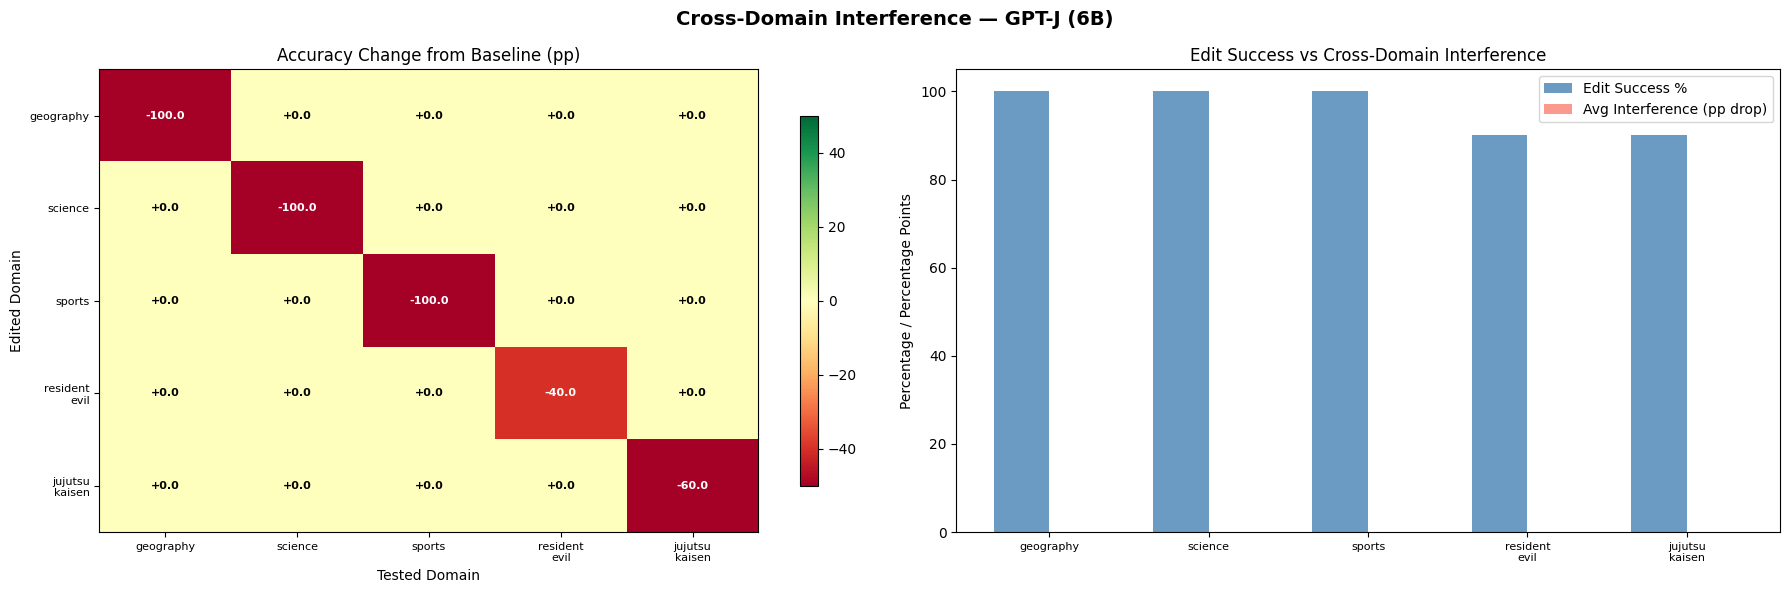

In [17]:
# ============================================================
# VISUALIZATION
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# 1. Interference heatmap
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Build delta matrix (change from baseline)
delta_matrix = np.zeros((len(domain_names), len(domain_names)))
for i, edit_d in enumerate(domain_names):
    for j, test_d in enumerate(domain_names):
        delta_matrix[i, j] = interference_matrix[edit_d][test_d] - baseline_acc[test_d]

ax = axes[0]
im = ax.imshow(delta_matrix, cmap="RdYlGn", vmin=-50, vmax=50, aspect="auto")
ax.set_xticks(range(len(domain_names)))
ax.set_yticks(range(len(domain_names)))
short_names = [d.replace("_", "\n") for d in domain_names]
ax.set_xticklabels(short_names, fontsize=8)
ax.set_yticklabels(short_names, fontsize=8)
ax.set_xlabel("Tested Domain")
ax.set_ylabel("Edited Domain")
ax.set_title("Accuracy Change from Baseline (pp)")
for i in range(len(domain_names)):
    for j in range(len(domain_names)):
        color = "white" if abs(delta_matrix[i, j]) > 25 else "black"
        ax.text(j, i, f"{delta_matrix[i, j]:+.1f}", ha="center", va="center",
                fontsize=8, color=color, fontweight="bold")
plt.colorbar(im, ax=ax, shrink=0.8)

# 2. Edit success + avg interference bar chart
ax = axes[1]
x = range(len(domain_names))
es_vals = [edit_success[d] for d in domain_names]
interf_vals = []
for edit_d in domain_names:
    drops = [baseline_acc[t] - interference_matrix[edit_d][t]
             for t in domain_names if t != edit_d]
    interf_vals.append(np.mean(drops))

width = 0.35
bars1 = ax.bar([i - width/2 for i in x], es_vals, width, color="steelblue", alpha=0.8, label="Edit Success %")
bars2 = ax.bar([i + width/2 for i in x], interf_vals, width, color="salmon", alpha=0.8, label="Avg Interference (pp drop)")
ax.set_xticks(x)
ax.set_xticklabels(short_names, fontsize=8)
ax.set_ylabel("Percentage / Percentage Points")
ax.set_title("Edit Success vs Cross-Domain Interference")
ax.legend()
ax.axhline(y=0, color="black", linewidth=0.5)

plt.suptitle(MODEL_TITLE, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"crossdomain_{MODEL_TAG}_results.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. Save Results

In [18]:
# ============================================================
# SAVE RESULTS
# ============================================================
import json, os

def make_serializable(obj):
    if isinstance(obj, dict):
        return {str(k): make_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [make_serializable(x) for x in obj]
    elif isinstance(obj, (int, float, str, bool)):
        return obj
    elif isinstance(obj, np.bool_):
        return bool(obj)
    else:
        try:
            return float(obj)
        except (TypeError, ValueError):
            return str(obj)

save_data = {
    "model": MODEL_NAME,
    "algorithm": "MEMIT",
    "experiment": "cross_domain_interference",
    "domains": {d: len(facts) for d, facts in domains.items()},
    "baseline_accuracy": make_serializable(baseline_acc),
    "interference_matrix": make_serializable(interference_matrix),
    "edit_success": make_serializable(edit_success),
}

local_path = f"crossdomain_{MODEL_TAG}_results.json"
with open(local_path, "w") as f:
    json.dump(save_data, f, indent=2)

try:
    import shutil
    SAVE_DIR = "/content/drive/MyDrive/MEMIT_Results"
    os.makedirs(SAVE_DIR, exist_ok=True)
    shutil.copy(local_path, f"{SAVE_DIR}/{local_path}")
    png = f"crossdomain_{MODEL_TAG}_results.png"
    if os.path.exists(png):
        shutil.copy(png, f"{SAVE_DIR}/{png}")
    print(f"Results saved to Google Drive: {SAVE_DIR}/")
except:
    print(f"Results saved locally as {local_path}")

print("\nDone!")


Results saved to Google Drive: /content/drive/MyDrive/MEMIT_Results/

Done!
